In [79]:
import pandas as pd
from sklearn.model_selection import train_test_split
import pickle
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [80]:
!pip install Sastrawi

In [81]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
cd /content/drive/MyDrive/PPW/tugas

/content/drive/MyDrive/PPW/tugas


# Load Data

In [83]:
df = pd.read_csv("Tugas-Crawling-Data-Berita-2-kategori.csv")

df

,NO,Judul Berita,Isi Berita,Tanggal Berita,Kategori Berita
0,1,"Analisis PPI: Di Tangan Presiden Prabowo, Indo...","TIMESINDONESIA, JAKARTA – Di bawah kepemimpina...",04/09/2024 - 23:35,Politik
1,2,"Bacawabup Lathifah Solidkan Seribu Relawan, Si...","TIMESINDONESIA, MALANG – Bakal cawabup Malang,...",04/09/2024 - 22:02,Politik
2,3,Rois Syuriah Sebut Visi Misi Untoro-Wahyudi Se...,"TIMESINDONESIA, BANTUL – Rois Syuriah PCNU Ban...",04/09/2024 - 20:54,Politik
3,4,Ribuan Kader PKB Kabupaten Mojokerto Panasi Me...,"TIMESINDONESIA, MOJOKERTO – Ribuan kader PKB K...",04/09/2024 - 19:23,Politik
4,5,"Wajah Pengurus Inti DPP PKB Tidak Berubah, Ini...","TIMESINDONESIA, JAKARTA – Partai Kebangkitan B...",04/09/2024 - 16:43,Politik
...,...,...,...,...,...
95,96,Azquira Scarf Luncurkan Hijab Autentik dengan ...,"TIMESINDONESIA, MALANG – Azquira Scarf menggel...",01/09/2024 - 22:42,Gaya Hidup
96,97,Mengulik Sejarah Bangunan Heritage Kota Malang...,"TIMESINDONESIA, MALANG – Pada Minggu (1/9/2024...",01/09/2024 - 22:16,Gaya Hidup
97,98,"Ritual Wewangian, Parfum Lokal Jadi Pilihan In...","TIMESINDONESIA, SURABAYA – Memilih wewangian p...",31/08/2024 - 20:04,Gaya Hidup
98,99,Berkeliling Nusantara Melalui Suguhan Kuliner ...,"TIMESINDONESIA, MAGELANG – Anda ingin mencicip...",04/09/2024 - 17:00,Gaya Hidup


# Data setelah Preprosessing



Preprosesing yang dilakukan :
- Label Encoder
- Cleaning
- Case Folding
- Tokenize
- Stop Word Removal
- Stemming

In [84]:
df_prep = pd.read_csv("/content/drive/MyDrive/PPW/tugas/data-preprosesing(klasifikasiberita).csv")

df_prep

,NO,Judul Berita,Isi Berita,Tanggal Berita,Kategori Berita,Kategori,cleansing,case_folding,tokenize,stopword_removal,stemming
0,1,"Analisis PPI: Di Tangan Presiden Prabowo, Indo...","TIMESINDONESIA, JAKARTA – Di bawah kepemimpina...",04/09/2024 - 23:35,Politik,0,TIMESINDONESIA JAKARTA Di bawah kepemimpinan ...,timesindonesia jakarta di bawah kepemimpinan ...,"['timesindonesia', 'jakarta', 'di', 'bawah', '...",timesindonesia jakarta kepemimpinan presiden r...,timesindonesia jakarta pimpin presiden ri prab...
1,2,"Bacawabup Lathifah Solidkan Seribu Relawan, Si...","TIMESINDONESIA, MALANG – Bakal cawabup Malang,...",04/09/2024 - 22:02,Politik,0,TIMESINDONESIA MALANG Bakal cawabup Malang La...,timesindonesia malang bakal cawabup malang la...,"['timesindonesia', 'malang', 'bakal', 'cawabup...",timesindonesia malang cawabup malang lathifah ...,timesindonesia malang cawabup malang lathifah ...
2,3,Rois Syuriah Sebut Visi Misi Untoro-Wahyudi Se...,"TIMESINDONESIA, BANTUL – Rois Syuriah PCNU Ban...",04/09/2024 - 20:54,Politik,0,TIMESINDONESIA BANTUL Rois Syuriah PCNU Bantu...,timesindonesia bantul rois syuriah pcnu bantu...,"['timesindonesia', 'bantul', 'rois', 'syuriah'...",timesindonesia bantul rois syuriah pcnu bantul...,timesindonesia bantul rois syuriah pcnu bantul...
3,4,Ribuan Kader PKB Kabupaten Mojokerto Panasi Me...,"TIMESINDONESIA, MOJOKERTO – Ribuan kader PKB K...",04/09/2024 - 19:23,Politik,0,TIMESINDONESIA MOJOKERTO Ribuan kader PKB Kab...,timesindonesia mojokerto ribuan kader pkb kab...,"['timesindonesia', 'mojokerto', 'ribuan', 'kad...",timesindonesia mojokerto ribuan kader pkb kabu...,timesindonesia mojokerto ribu kader pkb kabupa...
4,5,"Wajah Pengurus Inti DPP PKB Tidak Berubah, Ini...","TIMESINDONESIA, JAKARTA – Partai Kebangkitan B...",04/09/2024 - 16:43,Politik,0,TIMESINDONESIA JAKARTA Partai Kebangkitan Ban...,timesindonesia jakarta partai kebangkitan ban...,"['timesindonesia', 'jakarta', 'partai', 'keban...",timesindonesia jakarta partai kebangkitan bang...,timesindonesia jakarta partai bangkit bangsa p...
...,...,...,...,...,...,...,...,...,...,...,...
95,96,Azquira Scarf Luncurkan Hijab Autentik dengan ...,"TIMESINDONESIA, MALANG – Azquira Scarf menggel...",01/09/2024 - 22:42,Gaya Hidup,1,TIMESINDONESIA MALANG Azquira Scarf menggelar...,timesindonesia malang azquira scarf menggelar...,"['timesindonesia', 'malang', 'azquira', 'scarf...",timesindonesia malang azquira scarf menggelar ...,timesindonesia malang azquira scarf gelar acar...
96,97,Mengulik Sejarah Bangunan Heritage Kota Malang...,"TIMESINDONESIA, MALANG – Pada Minggu (1/9/2024...",01/09/2024 - 22:16,Gaya Hidup,1,TIMESINDONESIA MALANG Pada Minggu 192024 komu...,timesindonesia malang pada minggu 192024 komu...,"['timesindonesia', 'malang', 'pada', 'minggu',...",timesindonesia malang minggu 192024 komunitas ...,timesindonesia malang minggu 192024 komunitas ...
97,98,"Ritual Wewangian, Parfum Lokal Jadi Pilihan In...","TIMESINDONESIA, SURABAYA – Memilih wewangian p...",31/08/2024 - 20:04,Gaya Hidup,1,TIMESINDONESIA SURABAYA Memilih wewangian pen...,timesindonesia surabaya memilih wewangian pen...,"['timesindonesia', 'surabaya', 'memilih', 'wew...",timesindonesia surabaya memilih wewangian peng...,timesindonesia surabaya pilih wewangian harum ...
98,99,Berkeliling Nusantara Melalui Suguhan Kuliner ...,"TIMESINDONESIA, MAGELANG – Anda ingin mencicip...",04/09/2024 - 17:00,Gaya Hidup,1,TIMESINDONESIA MAGELANG Anda ingin mencicipi ...,timesindonesia magelang anda ingin mencicipi ...,"['timesindonesia', 'magelang', 'anda', 'ingin'...",timesindonesia magelang mencicipi kenikmatan s...,timesindonesia magelang cicip nikmat deret kul...


In [85]:
x = df_prep['stemming'].values
y = df_prep['Kategori'].values

Xtrain, Xtest,Ytrain,Ytest = train_test_split(x,y,test_size=0.2,random_state=2)

# TF-IDF

In [86]:
# Inisialisasi TfidfVectorizer
vect = TfidfVectorizer()

# Fitting dan transformasi data pelatihan (mengajarkan model tentang kata-kata di Xtrain dan menghitung TF-IDF)
X = vect.fit_transform(Xtrain)

# Mengonversi Xtrain menjadi representasi TF-IDF
X_array = vect.transform(Xtrain)

In [87]:
# Mengubah matriks menjadi array
X_array.toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.08404587],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.08404587],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

# Modeling

Model yang digunakan:
- Logistic Regression
- Support Vector Machine
- Random Forest
- Multinomial Naive Bayes

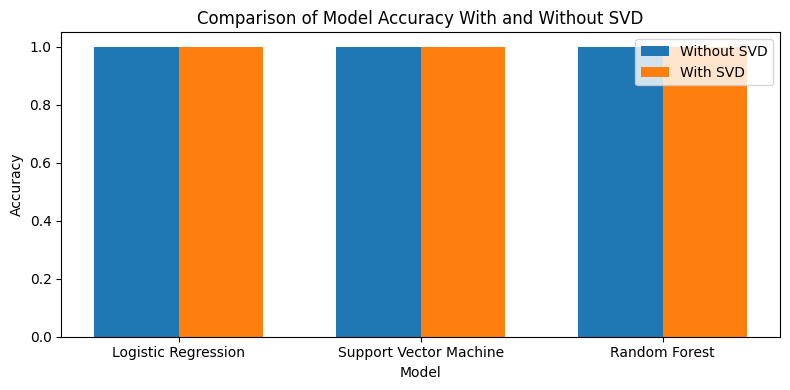

In [88]:
# Model dictionary
models = {
    "Logistic Regression": LogisticRegression(),
    "Support Vector Machine": SVC(),
    "Random Forest": RandomForestClassifier()
}

# Hasil akurasi
accuracy_results = {"Model": [], "With SVD": [], "Without SVD": []}

# Truncated SVD untuk reduksi dimensi
svd = TruncatedSVD(n_components=75, random_state=42)

# Transformasi data tes
X_test = vect.transform(Xtest)

# Loop untuk setiap model
for model_name, model in models.items():
    # Tanpa SVD
    model.fit(X, Ytrain)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(Ytest, y_pred)
    accuracy_results["Model"].append(model_name)
    accuracy_results["Without SVD"].append(accuracy)

    # Dengan SVD
    X_train_svd = svd.fit_transform(X)
    X_test_svd = svd.transform(X_test)
    model.fit(X_train_svd, Ytrain)
    y_pred_svd = model.predict(X_test_svd)
    accuracy_svd = accuracy_score(Ytest, y_pred_svd)
    accuracy_results["With SVD"].append(accuracy_svd)

# Konversi hasil ke DataFrame
accuracy_df = pd.DataFrame(accuracy_results)

# Plot perbandingan akurasi
plt.figure(figsize=(8, 4))
index = np.arange(len(accuracy_df["Model"]))
bar_width = 0.35

# Plot untuk akurasi tanpa SVD
plt.bar(index, accuracy_df["Without SVD"], bar_width, label="Without SVD")

# Plot untuk akurasi dengan SVD
plt.bar(index + bar_width, accuracy_df["With SVD"], bar_width, label="With SVD")

# Labeling
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracy With and Without SVD")
plt.xticks(index + bar_width / 2, accuracy_df["Model"])
plt.legend()
plt.tight_layout()
plt.show()

In [90]:
# Download stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [93]:
import re
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Preprocessing functions (sesuai dengan preprocessing yang telah Anda lakukan pada data)
def remove_symbols(data_berita):
    data_berita = re.sub(r'[^a-zA-Z0-9\s]', '', data_berita)  # Menghapus karakter non-alfanumerik
    return data_berita

def case_folding(text):
    if isinstance(text, str):
        return text.lower()  # Case folding menjadi lowercase
    return text

def tokenize(text):
    return text.split()  # Tokenisasi berdasarkan spasi

def remove_stopwords(text):
    return [word for word in text if word not in stop_words]  # Menghapus stopword

def stemming(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    return [stemmer.stem(word) for word in text]  # Stemming

# Fungsi untuk preprocessing input pengguna
def preprocess_user_input(user_text):
    user_text_cleaned = remove_symbols(user_text)  # Cleaning
    user_text_casefolded = case_folding(user_text_cleaned)  # Case folding
    user_text_tokenized = tokenize(user_text_casefolded)  # Tokenization
    user_text_no_stopwords = remove_stopwords(user_text_tokenized)  # Stopword removal
    user_text_stemmed = stemming(' '.join(user_text_no_stopwords))  # Stemming
    return ' '.join(user_text_stemmed)

# Fungsi untuk klasifikasi input pengguna
def classify_text(model_name, user_text, use_svd=False, n_components=100):
    # Memilih model yang diinginkan
    model = models[model_name]

    # Preprocessing input pengguna
    user_text_processed = preprocess_user_input(user_text)

    # Transformasi teks input yang telah diproses menjadi TF-IDF
    user_text_tfidf = vect.transform([user_text_processed])

    # Cek apakah menggunakan SVD atau tidak
    if use_svd:
        svd = TruncatedSVD(n_components=n_components, random_state=42)
        X_train_svd = svd.fit_transform(X)
        model.fit(X_train_svd, Ytrain)  # Train model with SVD-reduced data
        user_text_svd = svd.transform(user_text_tfidf)
        prediction = model.predict(user_text_svd)
    else:
        model.fit(X, Ytrain)  # Train model with full TF-IDF data
        prediction = model.predict(user_text_tfidf)

    # Mengonversi prediksi menjadi kategori
    category = "Gaya Hidup" if prediction[0] == 1 else "Politik"
    return category

# Dictionary pilihan model
model_options = {
    "1": "Logistic Regression",
    "2": "Support Vector Machine",
    "3": "Random Forest"
}

# Interaksi untuk pengguna
print("Pilihan Model:")
for key, value in model_options.items():
    print(f"{key}. {value}")

chosen_option = input("Pilih model untuk prediksi (masukkan nomor): ")
chosen_model = model_options.get(chosen_option)
if not chosen_model:
    print("Pilihan tidak valid.")
else:
    use_svd = input("Gunakan SVD untuk reduksi dimensi? (ya/tidak): ").strip().lower() == 'ya'

    # Jika memilih menggunakan SVD, minta jumlah komponen
    n_components = 75  # Default
    if use_svd:
        try:
            n_components = int(input("Masukkan jumlah komponen SVD: "))
        except ValueError:
            print("Input tidak valid. Menggunakan default n_components=100.")

    user_text = input("Masukkan teks berita untuk diklasifikasikan: ")

    # Lakukan klasifikasi
    predicted_category = classify_text(chosen_model, user_text, use_svd, n_components)
    print(f"Hasil prediksi kategori: {predicted_category}")

Pilihan Model:
1. Logistic Regression
2. Support Vector Machine
3. Random Forest
Pilih model untuk prediksi (masukkan nomor): 1
Gunakan SVD untuk reduksi dimensi? (ya/tidak): ya
Masukkan jumlah komponen SVD: 75
Masukkan teks berita untuk diklasifikasikan: TIMESINDONESIA, JEMBER – Sebanyak 142 barista dari berbagai daerah mengikuti Pandhalungan Coffee Week 2024 yang berlangsung di Main Atrium GF Lippo Plaza Jember, Jember, Jawa Timur (Jatim). Pandhalungan Coffee Week yang pertama kali digelar pada 2023 tersebut menjadi ajang berbagi cerita dan promosi bagi pecinta kopi Nusantara serta pelaku usaha yang tidak jauh dari biji kopi. "Jadi pada awalnya berdiri kegiatan ini di tahun 2023 itu hanya segmented untuk kopi. Kemudian pada tahun ini kami menginisiasi bahwa spektrumnya kami perluas," kata Resty Subagio selaku Ketua Panitia Pandhalungan Coffee Week saat ditemui di Lippo Plaza Jember, Sabtu (12/10/2024).  Resty mengatakan, Jember merupakan kabupaten yang dikenal sebagai salah satu peng

# nyoba lagi

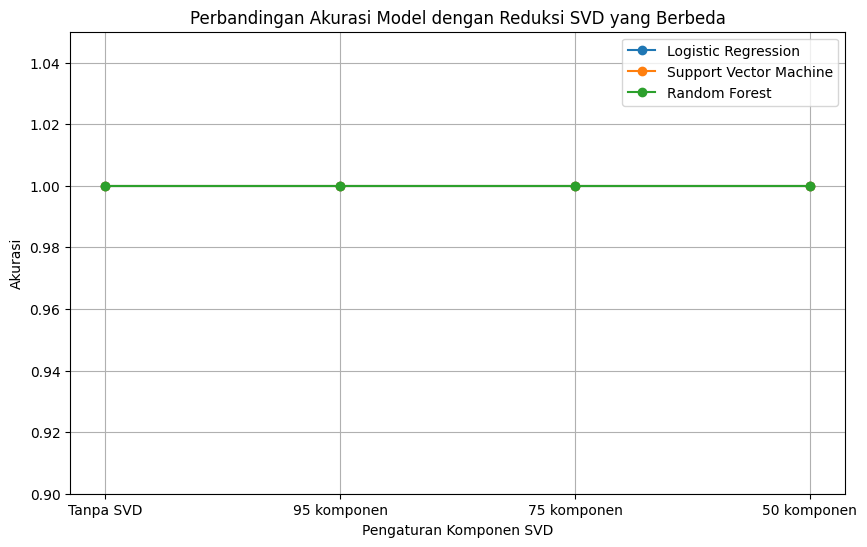

{'Logistic Regression (SVD=None)': '/content/drive/MyDrive/PPW/tugas/logistic_regression_svd_None.pkl',
 'Support Vector Machine (SVD=None)': '/content/drive/MyDrive/PPW/tugas/support_vector_machine_svd_None.pkl',
 'Random Forest (SVD=None)': '/content/drive/MyDrive/PPW/tugas/random_forest_svd_None.pkl',
 'Logistic Regression (SVD=95)': '/content/drive/MyDrive/PPW/tugas/logistic_regression_svd_95.pkl',
 'Support Vector Machine (SVD=95)': '/content/drive/MyDrive/PPW/tugas/support_vector_machine_svd_95.pkl',
 'Random Forest (SVD=95)': '/content/drive/MyDrive/PPW/tugas/random_forest_svd_95.pkl',
 'Logistic Regression (SVD=75)': '/content/drive/MyDrive/PPW/tugas/logistic_regression_svd_75.pkl',
 'Support Vector Machine (SVD=75)': '/content/drive/MyDrive/PPW/tugas/support_vector_machine_svd_75.pkl',
 'Random Forest (SVD=75)': '/content/drive/MyDrive/PPW/tugas/random_forest_svd_75.pkl',
 'Logistic Regression (SVD=50)': '/content/drive/MyDrive/PPW/tugas/logistic_regression_svd_50.pkl',
 'Supp

In [107]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pickle

# Memuat dataset
df_prep = pd.read_csv('/content/drive/MyDrive/PPW/tugas/data-preprosesing(klasifikasiberita).csv')

# Mendefinisikan fitur dan variabel target
x = df_prep['stemming'].values
y = df_prep['Kategori'].values

# Membagi data menjadi set pelatihan dan pengujian
X_train_raw, X_test_raw, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

# Transformasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_raw)
X_test_tfidf = tfidf_vectorizer.transform(X_test_raw) #ditransformasikan menggunakan transformasi yang sama (berdasarkan fit dari data pelatihan).

# Menyimpan TF-IDF vectorizer ke dalam file PKL
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf_vectorizer, file)

# Model yang akan dievaluasi
models = {
    'Logistic Regression': LogisticRegression(),
    'Support Vector Machine': SVC(),
    'Random Forest': RandomForestClassifier()
}

# Komponen SVD untuk reduksi dimensi
svd_components = [None, 95, 75, 50]

# Menyimpan hasil
results = {model_name: [] for model_name in models.keys()}
model_files = {}

# Melatih dan mengevaluasi setiap model dengan pengaturan SVD yang berbeda
for n_components in svd_components:
    # Menerapkan SVD jika n_components ditentukan
    if n_components:
        svd = TruncatedSVD(n_components=n_components, random_state=2)
        X_train = svd.fit_transform(X_train_tfidf)
        X_test = svd.transform(X_test_tfidf)

        # Simpan objek SVD
        svd_filename = f'/content/drive/MyDrive/PPW/tugas/svd_{n_components}.pkl'
        with open(svd_filename, 'wb') as file:
            pickle.dump(svd, file)
    else:
        X_train, X_test = X_train_tfidf, X_test_tfidf

    # Melatih dan menyimpan setiap model
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)

        # Menyimpan akurasi model
        results[model_name].append(accuracy)

        # Menyimpan model yang telah dilatih ke file PKL
        model_filename = f'/content/drive/MyDrive/PPW/tugas/{model_name.replace(" ", "_").lower()}_svd_{n_components}.pkl'
        with open(model_filename, 'wb') as file:
            pickle.dump(model, file)

        model_files[f"{model_name} (SVD={n_components})"] = model_filename

# Membuat plot perbandingan akurasi
component_labels = ['Tanpa SVD', '95 komponen', '75 komponen', '50 komponen']
plt.figure(figsize=(10, 6))
for model_name, accuracies in results.items():
    plt.plot(component_labels, accuracies, marker='o', label=model_name)

plt.title('Perbandingan Akurasi Model dengan Reduksi SVD yang Berbeda')
plt.xlabel('Pengaturan Komponen SVD')
plt.ylabel('Akurasi')
plt.ylim(0.9, 1.05)
plt.legend()
plt.grid(True)
plt.show()

# Menampilkan path file model untuk referensi
model_files

# Implementasi User

In [108]:
import re
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

# Preprocessing functions

# Cleaning
def remove_symbols(data_berita):
    data_berita = re.sub(r'[^a-zA-Z0-9\s]', '', data_berita)  # Menghapus karakter yang tidak diinginkan
    return data_berita

# Case Folding
def case_folding(text):
    if isinstance(text, str):
        return text.lower()  # Mengubah teks menjadi huruf kecil
    return text

# Tokenizing
def tokenize(text):
    tokens = text.split()  # Memecah teks menjadi token (kata-kata)
    return tokens

# Stopword Removal
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

def remove_stopwords(text):
    return [word for word in text if word not in stop_words]  # Menghapus stopwords

# Stemming
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(text):
    return [stemmer.stem(word) for word in text]  # Melakukan stemming

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [109]:
def preprocess_user_input(berita):
    # Step by step preprocessing
    cleaned = remove_symbols(berita)
    folded = case_folding(cleaned)
    tokenized = tokenize(folded)
    no_stopwords = remove_stopwords(tokenized)
    stemmed = stemming(no_stopwords)

    # Gabungkan kembali menjadi teks setelah stemming
    preprocessed_text = ' '.join(stemmed)
    return preprocessed_text

In [110]:
import pickle

# Memuat TF-IDF Vectorizer
with open('tfidf_vectorizer.pkl', 'rb') as file:
    tfidf_vectorizer = pickle.load(file)

# Fungsi untuk memuat model yang diinginkan
def load_model(model_filename):
    with open(model_filename, 'rb') as file:
        model = pickle.load(file)
    return model

In [111]:
def predict_category(berita, model_filename, svd_filename=None):
    # Preprocessing input user
    preprocessed_berita = preprocess_user_input(berita)

    # Transformasi TF-IDF
    tfidf_berita = tfidf_vectorizer.transform([preprocessed_berita])

    # Jika ada reduksi dimensi (SVD), terapkan SVD
    if svd_filename:
        with open(svd_filename, 'rb') as file:
            svd = pickle.load(file)
        tfidf_berita = svd.transform(tfidf_berita)

    # Memuat model yang dipilih user
    model = load_model(model_filename)

    # Prediksi kategori
    predicted_category = model.predict(tfidf_berita)

    return predicted_category[0]  # Mengembalikan hasil prediksi

In [113]:
# Input berita dari user
input_berita = input("Masukkan isi berita yang ingin diprediksi kategorinya: ")

# Pilihan model oleh user
print("Pilih model untuk prediksi:")
print("1. Logistic Regression")
print("2. Support Vector Machine (SVM)")
print("3. Random Forest")
model_option = input("Masukkan pilihan model (1/2/3): ")

if model_option == '1':
    model_choice = "logistic_regression"
elif model_option == '2':
    model_choice = "svm"
elif model_option == '3':
    model_choice = "random_forest"
else:
    print("Pilihan tidak valid. Menggunakan Logistic Regression sebagai default.")
    model_choice = "logistic_regression"

# Pilihan komponen SVD oleh user
print("Pilih jumlah komponen SVD untuk reduksi dimensi:")
print("1. Tanpa SVD")
print("2. 95 komponen")
print("3. 75 komponen")
print("4. 50 komponen")
svd_option = input("Masukkan pilihan komponen SVD (1/2/3/4): ")

if svd_option == '1':
    svd_components = None
elif svd_option == '2':
    svd_components = 95
elif svd_option == '3':
    svd_components = 75
elif svd_option == '4':
    svd_components = 50
else:
    print("Pilihan tidak valid. Tidak menggunakan SVD sebagai default.")
    svd_components = None

# Path model dan SVD sesuai pilihan
model_filename = f'/content/drive/MyDrive/PPW/tugas/{model_choice}_svd_{svd_components}.pkl'
svd_filename = None if svd_components is None else f'/content/drive/MyDrive/PPW/tugas/svd_{svd_components}.pkl'

# Prediksi kategori
predicted_category = predict_category(input_berita, model_filename, svd_filename)

# Tampilkan hasil prediksi
print(f"Kategori prediksi untuk berita tersebut adalah: {predicted_category}")

Masukkan isi berita yang ingin diprediksi kategorinya: TIMESINDONESIA, JEMBER – Sebanyak 142 barista dari berbagai daerah mengikuti Pandhalungan Coffee Week 2024 yang berlangsung di Main Atrium GF Lippo Plaza Jember, Jember, Jawa Timur (Jatim). Pandhalungan Coffee Week yang pertama kali digelar pada 2023 tersebut menjadi ajang berbagi cerita dan promosi bagi pecinta kopi Nusantara serta pelaku usaha yang tidak jauh dari biji kopi. "Jadi pada awalnya berdiri kegiatan ini di tahun 2023 itu hanya segmented untuk kopi. Kemudian pada tahun ini kami menginisiasi bahwa spektrumnya kami perluas," kata Resty Subagio selaku Ketua Panitia Pandhalungan Coffee Week saat ditemui di Lippo Plaza Jember, Sabtu (12/10/2024).  Resty mengatakan, Jember merupakan kabupaten yang dikenal sebagai salah satu penghasil kopi terbaik di Indonesia, khususnya kopi robusta.  Namun, dia menyatakan bahwa perhatian terhadap potensi kopi di Jember masih kurang.  "Harapannya setelah ada klaim seperti itu, kami ingin puny